In [1]:
from math import log

def CGUM(
    f1_unl,
    f1_gold,
    mia_unl,
    mia_gold,
    mia_orig,
    time_unl,
    time_gold,
    C,
    alpha=1,
    beta=1,
):
    eps = 1e-6

    # Utility
    f1_random = 1 / C
    U = (f1_unl - f1_random) / (f1_gold - f1_random + eps)
    U = max(0, min(1, U))

    # Efficacy
    if mia_orig >= mia_gold:
        mia_unl_sat = min(mia_unl, mia_orig)
    else:
        mia_unl_sat = max(mia_unl, mia_orig)

    E = 1 - abs(mia_unl_sat - mia_gold) / (abs(mia_orig - mia_gold) + eps)
    E = max(0, min(1, E))

    # Efficiency
    T = 1 - (log(time_unl + 1) / (log(time_gold + 1) + eps))
    T = max(0, min(1, T))

    numerator = (1 + alpha + beta) * U * E * T
    denominator = alpha * E * T + beta * U * T + U * E + eps

    return numerator / denominator

In [2]:
# Example usage
score = CGUM(0.82, 0.90, 0.54, 0.60, 0.62, 120.0, 150.0, C=10)
score

0.0

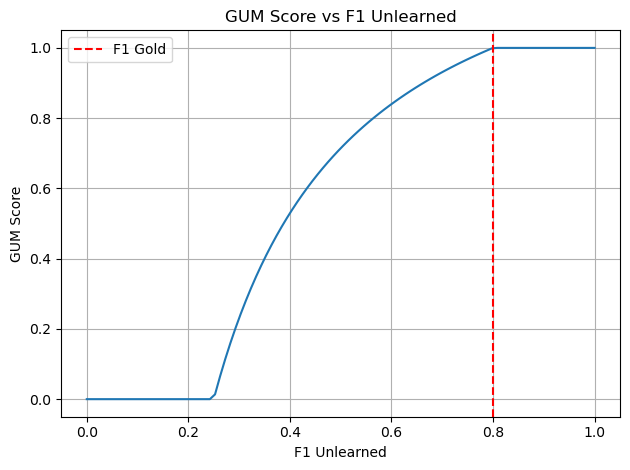

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

f1_gold = 0.8
mia_gold = 0.5
mia_full = 0.8
mia_unl = 0.5  
time_unl = 0
time_gold = 100
C = 4 
f1_unl_values = np.linspace(0, 1, 100)
gum_scores_1 = []
for f1_unl in f1_unl_values:
    gum_score = CGUM(f1_unl, f1_gold, mia_unl, mia_gold, mia_full, time_unl, time_gold, C)
    gum_scores_1.append(gum_score)

plt.plot(f1_unl_values, gum_scores_1)
plt.xlabel('F1 Unlearned')
plt.ylabel('GUM Score')
plt.title('GUM Score vs F1 Unlearned')
plt.grid()
plt.axvline(x=f1_gold, color='red', linestyle='--', label='F1 Gold')
plt.legend()
plt.tight_layout()
plt.show()

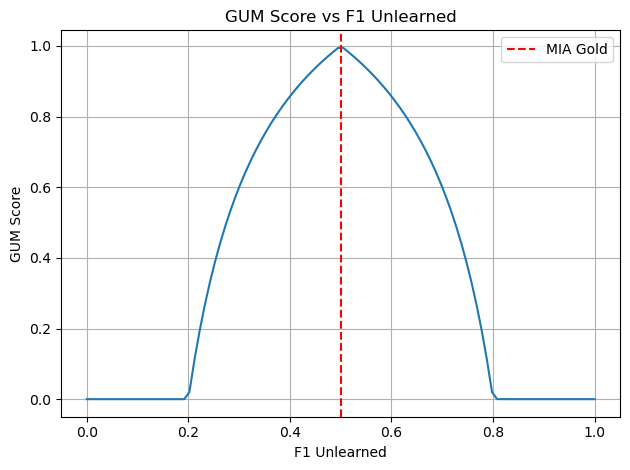

In [4]:
f1_gold = 0.8
mia_gold = 0.5
mia_full = 0.8
f1_unl = 0.8
time_unl = 0 
time_gold = 100
C = 4 
mia_unl_values = np.linspace(0, 1, 100)  
gum_scores = []
for mia_unl in mia_unl_values:
    gum_score = CGUM(f1_unl, f1_gold, mia_unl, mia_gold, mia_full, time_unl, time_gold, C)
    gum_scores.append(gum_score)

plt.plot(mia_unl_values, gum_scores)
plt.xlabel('F1 Unlearned')
plt.ylabel('GUM Score')
plt.title('GUM Score vs F1 Unlearned')
plt.grid()
plt.axvline(x=mia_gold, color='red', linestyle='--', label='MIA Gold')
plt.legend()
plt.tight_layout()
plt.show()

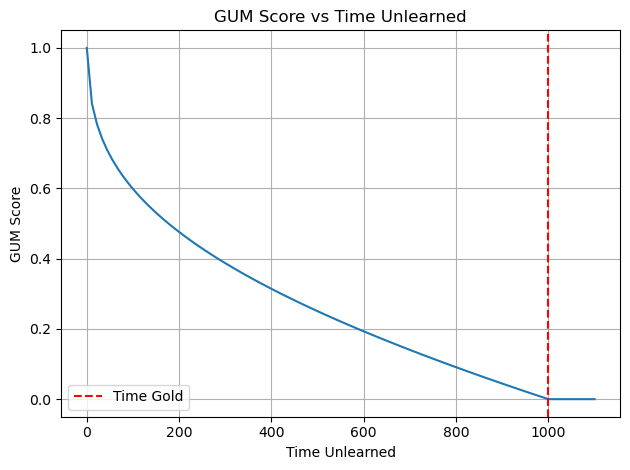

In [5]:
f1_gold = 0.8
f1_unl = 0.8
mia_gold = 0.5
mia_full = 0.8
mia_unl = 0.5  
time_gold = 1000
C = 4 
time_unl_values = np.linspace(0, 1100, 100)
gum_scores_3 = []
for time_unl in time_unl_values:
    gum_score = CGUM(f1_unl, f1_gold, mia_unl, mia_gold, mia_full, time_unl, time_gold, C)
    gum_scores_3.append(gum_score)

plt.plot(time_unl_values, gum_scores_3)
plt.xlabel('Time Unlearned')
plt.ylabel('GUM Score')
plt.title('GUM Score vs Time Unlearned')
plt.grid()
plt.axvline(x=time_gold, color='red', linestyle='--', label='Time Gold')
plt.legend()
plt.tight_layout()
plt.show()

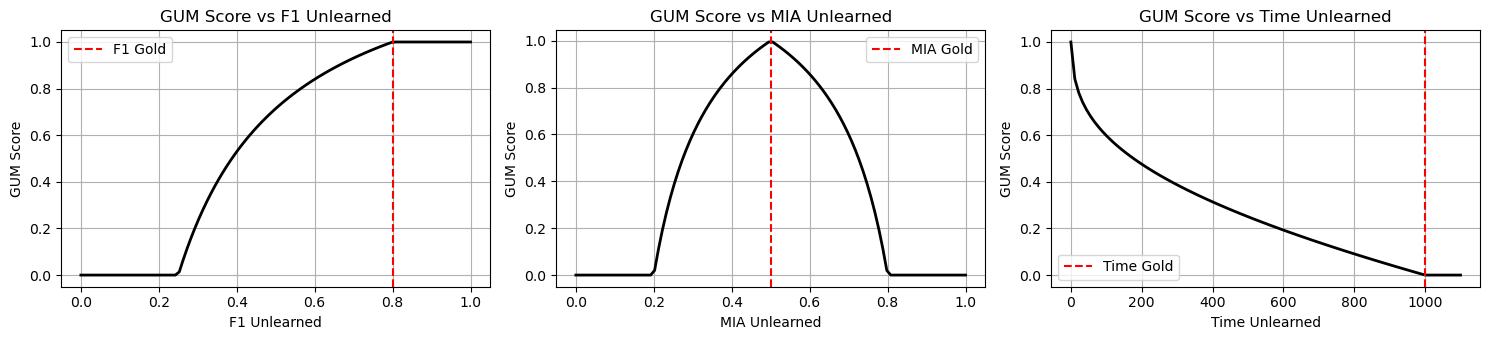

In [7]:
# put the three plots one near the other 

plt.figure(figsize=(15, 3.5))
plt.subplot(1, 3, 1)
plt.plot(f1_unl_values, gum_scores_1, linewidth=2, color='black')
plt.xlabel('F1 Unlearned')
plt.ylabel('GUM Score')
plt.title('GUM Score vs F1 Unlearned')
plt.grid()
plt.axvline(x=f1_gold, color='red', linestyle='--', linewidth=1.5, label='F1 Gold')
plt.legend()    

plt.subplot(1, 3, 2)
plt.plot(mia_unl_values, gum_scores, linewidth=2, color='black')
plt.xlabel('MIA Unlearned')
plt.ylabel('GUM Score')
plt.title('GUM Score vs MIA Unlearned')
plt.grid()
plt.axvline(x=mia_gold, color='red', linestyle='--', linewidth=1.5, label='MIA Gold')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(time_unl_values, gum_scores_3, linewidth=2, color='black')
plt.xlabel('Time Unlearned')
plt.ylabel('GUM Score')
plt.title('GUM Score vs Time Unlearned')
plt.grid()
plt.axvline(x=time_gold, color='red', linestyle='--', linewidth=1.5, label='Time Gold')
plt.legend()
plt.tight_layout()
plt.show()